# Explore here

In [2]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv',delimiter=',')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.to_csv('../data/raw/datos_airbnb_nyc.csv',index=False)

## Paso 1 : Plantear el problema

Prediccion de precios en NYC para Airbnb

## Paso 2: Exploracion y Limpieza

In [5]:
# Forma del DataFrame (filas y columnas)
df.shape


(48895, 16)

In [6]:
#Obtener informacion sobre los tipos de datos y valores nulos de cada columna 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

Tenemos 48.895 filas  y 16 columnas 
Tambien tenemos muchos valores nulos en las columnas last_review y reviews_per_month faltan 10.052 datos 

De los tipos de datos podemos inferir que hay 10 variables numericas y  6 variables categoricas


In [7]:
#Analizar si hay duplicados sin una columna 
print(df.drop(columns=['id']).duplicated().sum())

#Analizar si hay ids duplicados 
print(df['id'].duplicated().sum())

#Analizar si hay duplicados considerando todas las columnas 
print(f'Número de filas duplicadas: {df.duplicated().sum()}')


0
0
Número de filas duplicadas: 0


Por el codigo anterior no existen duplicados 

In [8]:
#Si existieran duplicados, se tendria que usar el siguiente código
if df.duplicated().sum():
    df = df.drop_duplicates()
print(df.shape)

(48895, 16)


## Análisis de Columnas irrelevantes

In [9]:
#Cuales son las columnas que se tienen
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [10]:
#Cuales son los datos de las columnas irrelevantes que se tienen 
df.drop(['id','name','host_id','host_name','last_review','reviews_per_month'],axis=1,inplace=True)
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


## Conclusiones 
- Id y host_id son codigos de identificacion 
- Name y host_id son los nombres de identificacion de las propiedades
- Last_review es la fecha de cuando fue el ultimo comentario 
- Reviews_per_month es el total de reseñas del mes 

## Paso 3 : Analisis Univariante



## Analisis de variables categoricas

In [11]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   calculated_host_listings_count  48895 non-null  int64  
 9   availability_365                48895 non-null  int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 3.7 MB


Se tienen todas las columnas con valores completos

48895 datos contienen cada una de las columnas 

Teniendo 7 columnas numericas y 3 de texto 


## Construccion de Graficos 

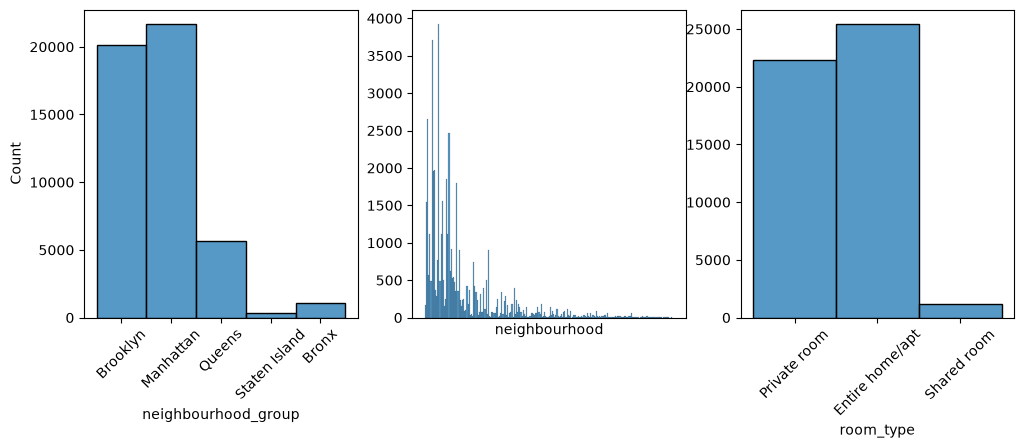

In [12]:
fig, axis = plt.subplots(1,3,figsize=(12,4))

# Histogramas
sns.histplot(ax = axis[0], data = df , x = 'neighbourhood_group')
axis[0].tick_params(axis='x',rotation=45)
sns.histplot(ax = axis[1], data = df , x = 'neighbourhood').set_xticks([])
axis[1].set_ylabel(None)
sns.histplot(ax = axis[2], data = df , x = 'room_type')
axis[2].tick_params(axis='x',rotation=45)
axis[2].set_ylabel(None)

plt.tight_layout
plt.show()

## Conclusiones 
 - El grafico #1 Neighbourhood_group se tienen las 5 ubicaciones de los barrios/ distritos de la ciudad de NY con respecto a la cant de alojamientos que se tienen Brooklyn tiene 20.000 , Manhattan tiene mas de 20.0000 , Queens tiene 5.000 ,Staten Island y Bronx tienen muy pocos alojamientos 

 - El grafico #2 muestra los barrios especificos, donde se logra ver que en pocos barrios/distritos se tiene la mayor cant. de alojamientos 

 - El grafico #3 tenemos el tipo de habitacion que tiene el alojamiento: en Entire home/apt existe + de 25.000 , Private room tiene + de 20.000 y  Shared room son muy pocos 

## Analisis de variables numericas 

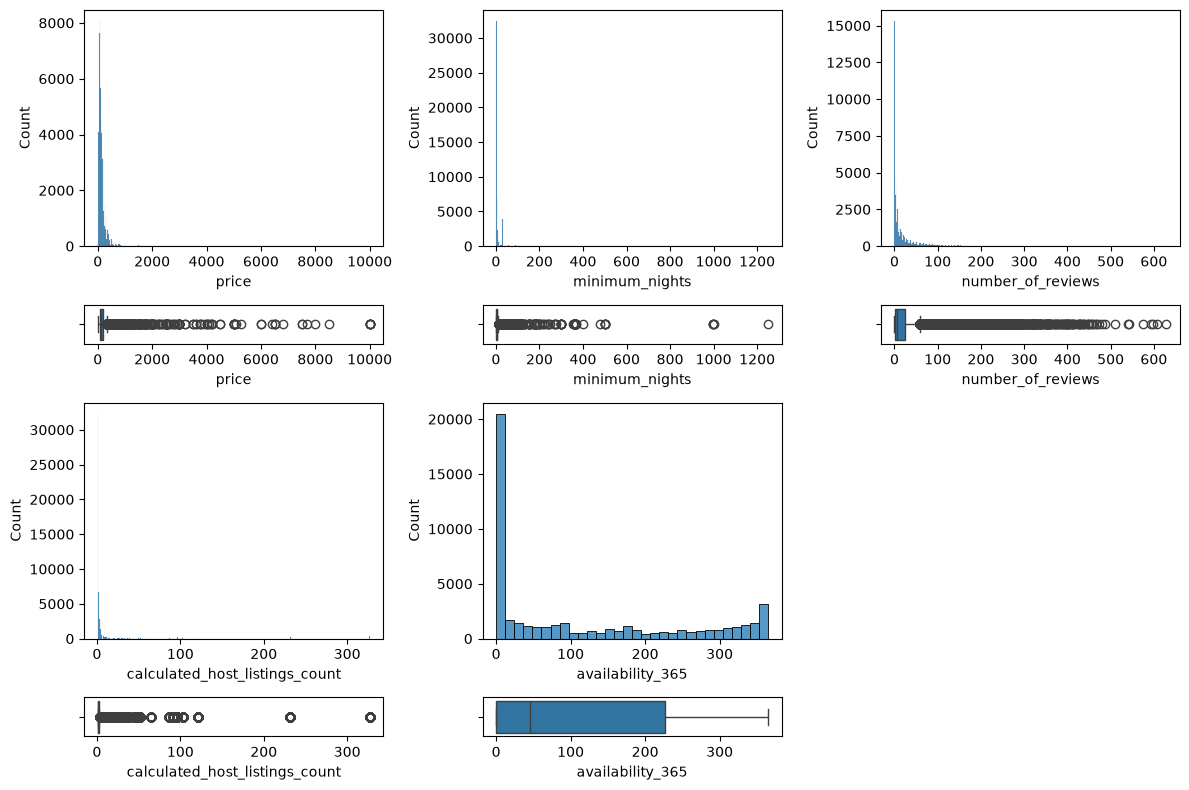

In [13]:
fig,axis = plt.subplots(4,3,figsize=(12,8),gridspec_kw= {"height_ratios":[6,1,6,1]})

sns.histplot(ax = axis[0,0],data=df,x="price")
sns.boxplot(ax=axis[1,0],data=df,x="price")

sns.histplot(ax = axis[0,1],data=df,x="minimum_nights")
sns.boxplot(ax=axis[1,1],data=df,x="minimum_nights")

sns.histplot(ax = axis[0,2],data=df,x="number_of_reviews")
sns.boxplot(ax=axis[1,2],data=df,x="number_of_reviews")

sns.histplot(ax = axis[2,0],data=df,x="calculated_host_listings_count")
sns.boxplot(ax=axis[3,0],data=df,x="calculated_host_listings_count")

sns.histplot(ax = axis[2,1],data=df,x="availability_365")
sns.boxplot(ax=axis[3,1],data=df,x="availability_365")

fig.delaxes(axis[2,2])
fig.delaxes(axis[3,2])

plt.tight_layout()
plt.show()

## Conclusiones 
 - El grafico #1 la mayoria de los alojamientos son economicos y se concentra en precios menores a 2.000 dolares y  el valor atipico es 10.000 dolares 

 - El grafico #2 demuestra la cantidad de noches alquiladas, se demuestra que la mayoria de las personas alquila por periodos cortos (1 a 3 noches )

 - El grafico #3  demuestra la cantidad de numero de reseñas, la mayoria tiene muy pocas reseñas, y las que tienen muchas reseñas que son pocos alojamientos tienen alrededor de 500-600 comentarios 

 - El grafico #4 da a conocer la cantidad de alojamientos por anfitrion, la mayoria tienen una sola propiedad o dos propiedades.Pero existen agencias inmobiliarias que tienen muchas propiedades 

 - El grafico #5 es la disponibilidad a lo largo del año, existen propiedades que casi nunca estan disponibles  y otras propiedades que estan disponibles durante todo el año

## Paso 4: Análisis Multivariante 

##  Numerico - Numerico 

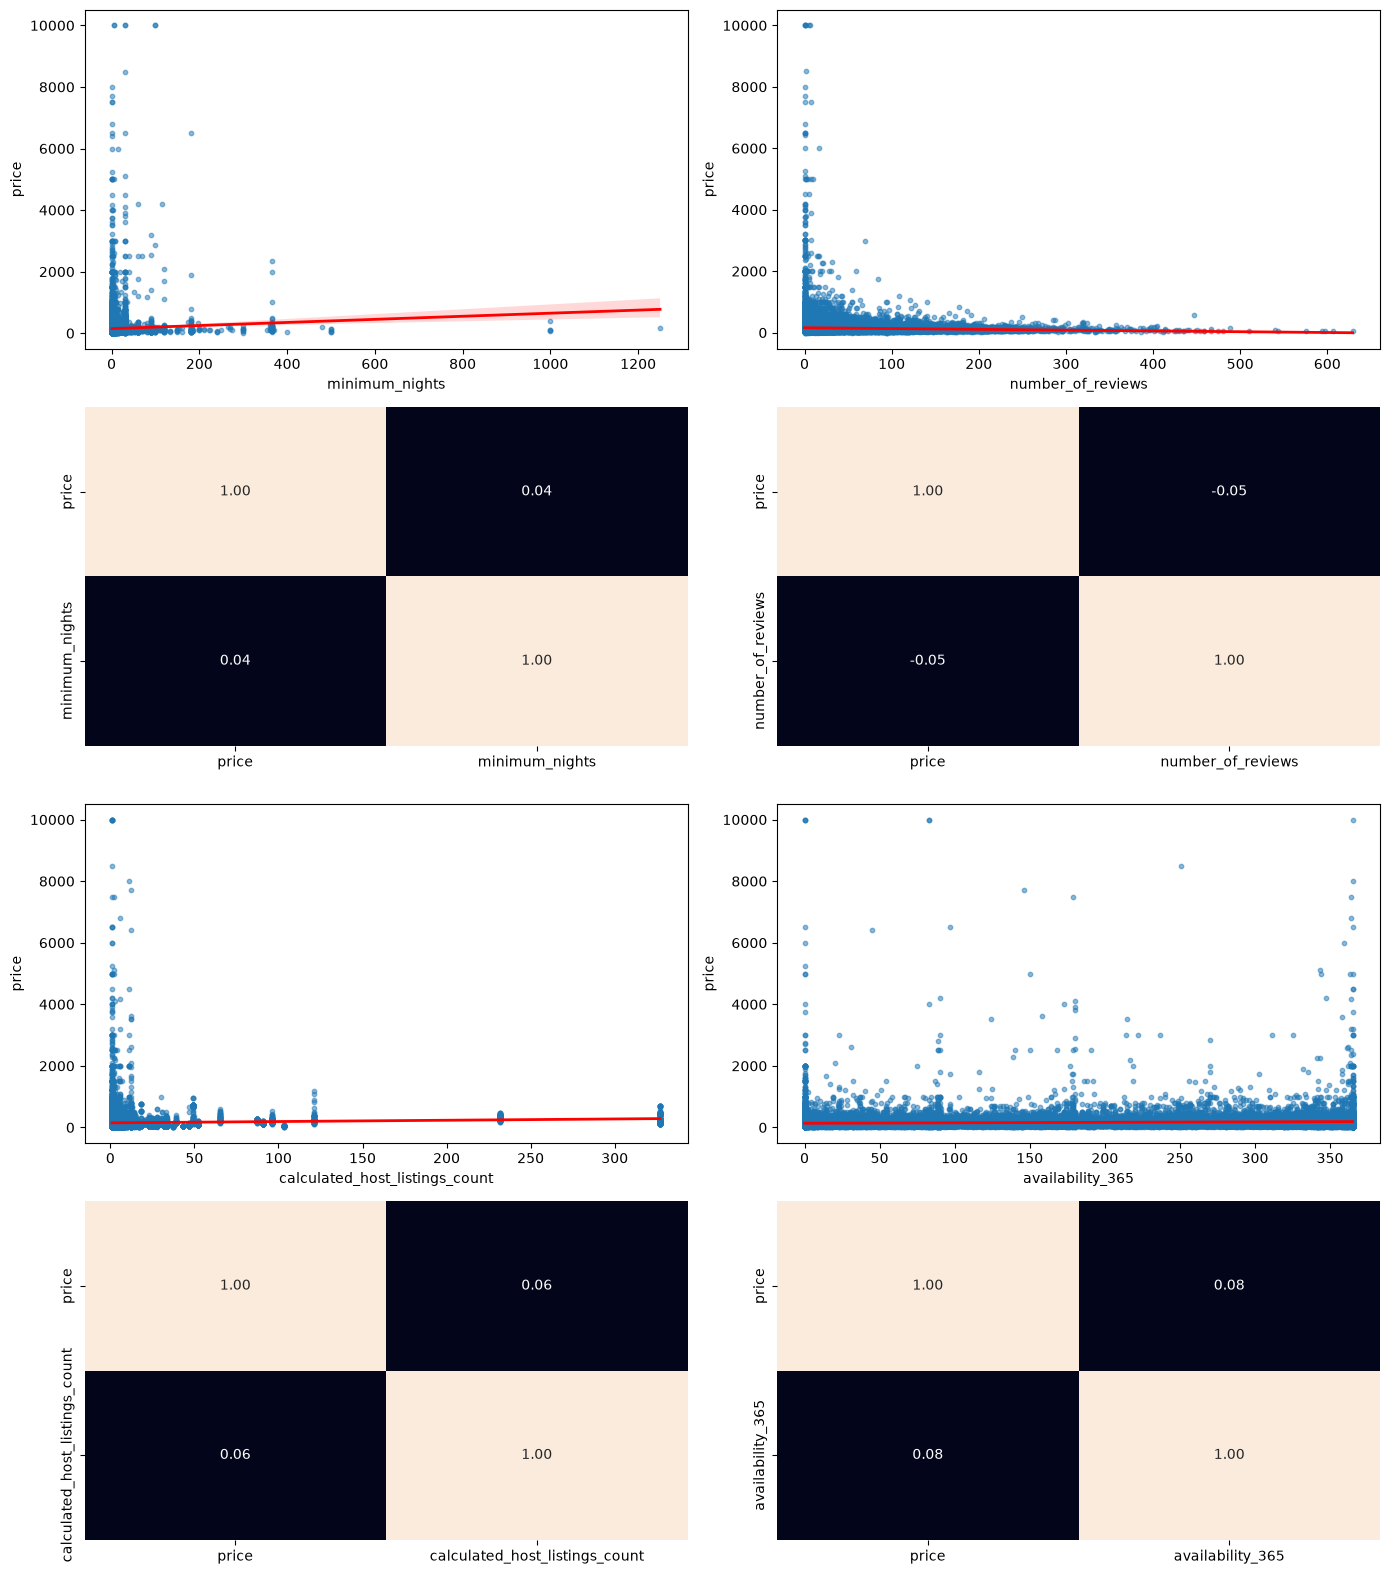

In [14]:
fig, axis = plt.subplots(4,2,figsize=(14,16))

sns.regplot(ax=axis[0,0],data=df,x="minimum_nights",y="price",scatter_kws={'s': 10,'alpha':0.5},line_kws={'color': 'red', 'linewidth': 2})
sns.heatmap(df[["price","minimum_nights"]].corr(),annot=True,fmt='.2f',ax=axis[1,0],cbar=False)

sns.regplot(ax=axis[0,1],data=df,x="number_of_reviews",y="price",scatter_kws={'s': 10,'alpha':0.5},line_kws={'color': 'red', 'linewidth': 2})
sns.heatmap(df[["price","number_of_reviews"]].corr(),annot=True,fmt='.2f',ax=axis[1,1],cbar=False)

sns.regplot(ax=axis[2,0],data=df,x="calculated_host_listings_count",y="price",scatter_kws={'s': 10,'alpha':0.5},line_kws={'color': 'red', 'linewidth': 2})
sns.heatmap(df[["price","calculated_host_listings_count"]].corr(),annot=True,fmt='.2f',ax=axis[3,0],cbar=False)

sns.regplot(ax=axis[2,1],data=df,x="availability_365",y="price",scatter_kws={'s': 10,'alpha':0.5},line_kws={'color': 'red', 'linewidth': 2})
sns.heatmap(df[["price","availability_365"]].corr(),annot=True,fmt='.2f',ax=axis[3,1],cbar=False)

plt.tight_layout()

plt.show()

## Conclusiones
- Grafico #1 (Grafico izquierdo superior) Precio vs. Noches minimas se muestra una linea de tendencia poco inclinada hacia arriba, tiene el grafico de correlacion abajo y demuestra una de 0.04, señalando que el precio por mas noches vaya a ser mas bajo o mas alto 

- Grafico #2 (Grafico derecho superior) Precio vs. # de reseñas  muestra una linea roja baja muy sutil y el grafico de abajo y demuestra la correlacion es de -0,05, se ve que los que tienen muchas reseñas por lo general son los mas economicos. El numero de comentarios no determina el precio.Las propiedades con un volumen grande de reseñas suelen mantener los precios bajos y accesibles.  

- Grafico #3 (Grafico izquierdo inferior) Precio vs. Alojamientos por anfitrion se muestra una linea que es plana y grafico de abajo demuestra el numero de correlación que es de 0,06.

- Grafico #4 (Grafico derecho inferior) Precio vs. Disponibilidad al año la linea de tendencia es es completamente horizontal y el grafico de correlacion es de 0,08.





# Categorico - Categorico


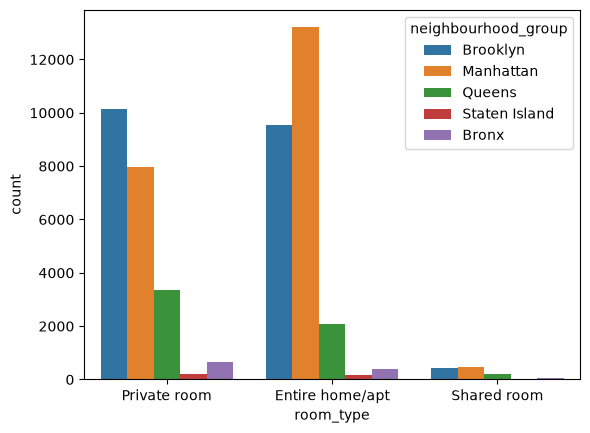

In [15]:
sns.countplot(data=df,x="room_type", hue = "neighbourhood_group")
plt.show()

En este grafico esta agrupado por el barrio/distrito de NY y el tipo de alojamiento 
- Brooklyn tiene el color azul: Entire home/apt menos de 10.000, Private room tiene 10.000 y Shared room son muy pocos.

-  Manhattan tiene el color naranja: Entire home/apt mas de 12.000 , Private room tiene 8.000 y  Shared room son muy pocos.

- Queens tiene el color verde: Entire home/apt tiene de 2.000 , Private room menos de 4.000 y  Shared room son muy pocos.

- Staten Island el color rojo: Entire home/apt pocos en comparacion con los demas colores , Private room es el menor en esta categoria  y  Shared room son casi nulos.

- Bronx tiene el color lila: Entire home/apt se encuentra de penultimo , Private room es mayor  Staten Island y  Shared room es casi inexistente.

## Numerico - Categorico

In [16]:
#transformar variables categoricas a numéricas
df['room_type']=pd.factorize(df['room_type'])[0]
df['neighbourhood_group']=pd.factorize(df['neighbourhood_group'])[0]
df['neighbourhood']=pd.factorize(df['neighbourhood'])[0]

df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,0,0,40.64749,-73.97237,0,149,1,9,6,365
1,1,1,40.75362,-73.98377,1,225,1,45,2,355
2,1,2,40.80902,-73.94190,0,150,3,0,1,365
3,0,3,40.68514,-73.95976,1,89,1,270,1,194
4,1,4,40.79851,-73.94399,1,80,10,9,1,0



Se transforman variables que son categoricas a numeros, lo que facilita la interpretacion de los datos, para asi generar una matriz de correlacion para luego realizar el analisis 

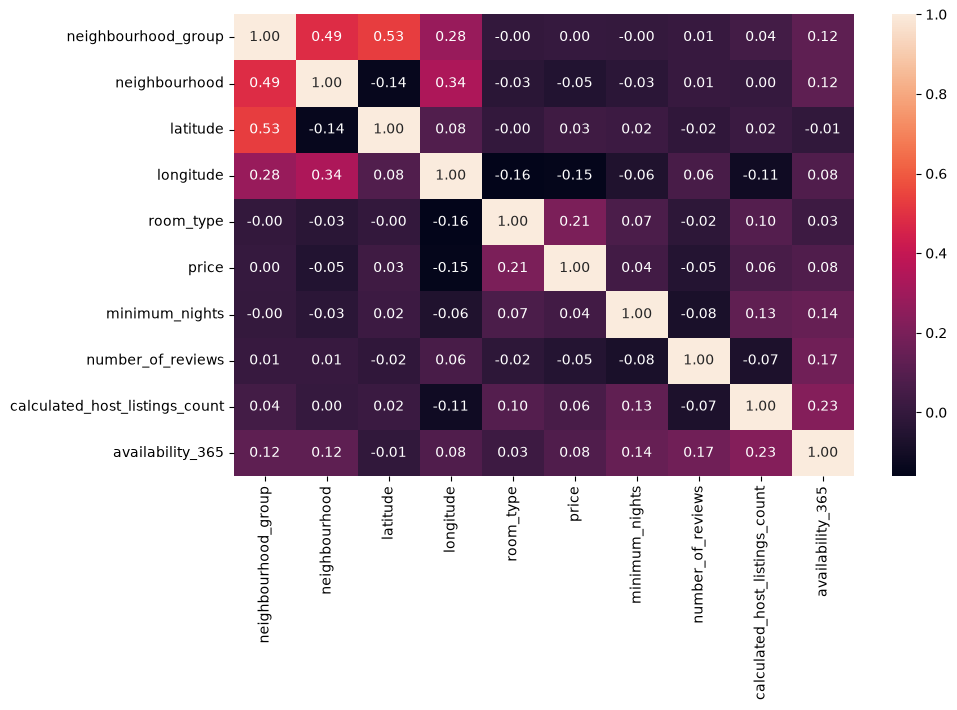

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,fmt='.2f')
plt.show()

## Conclusiones
- Al haber transformado la data categorias a numero podemos ver como las variables estan relacionadas entre si, cuando esta en 0 no hay relacion y mientras esta mas alejado del 0 la relacion es mas grande

- Se puede observar que la mayoria del cuadro es morado, se encuentra en 0 - 0.2, en un puntos especificos en la esquina superior izq. estan colores claros en 0.28-0.53 lo que significa que hay algun tipo de relacion con la latitud, longitud, barrio/distrito estan conectados.

- Los que tienen muchas propiedades las mantienen disponibles casi todo el año para ganar mas dinero. Mientras, que las personas que solo tienen una casa la alquilan menos dias al año o solo en fechas especificas.



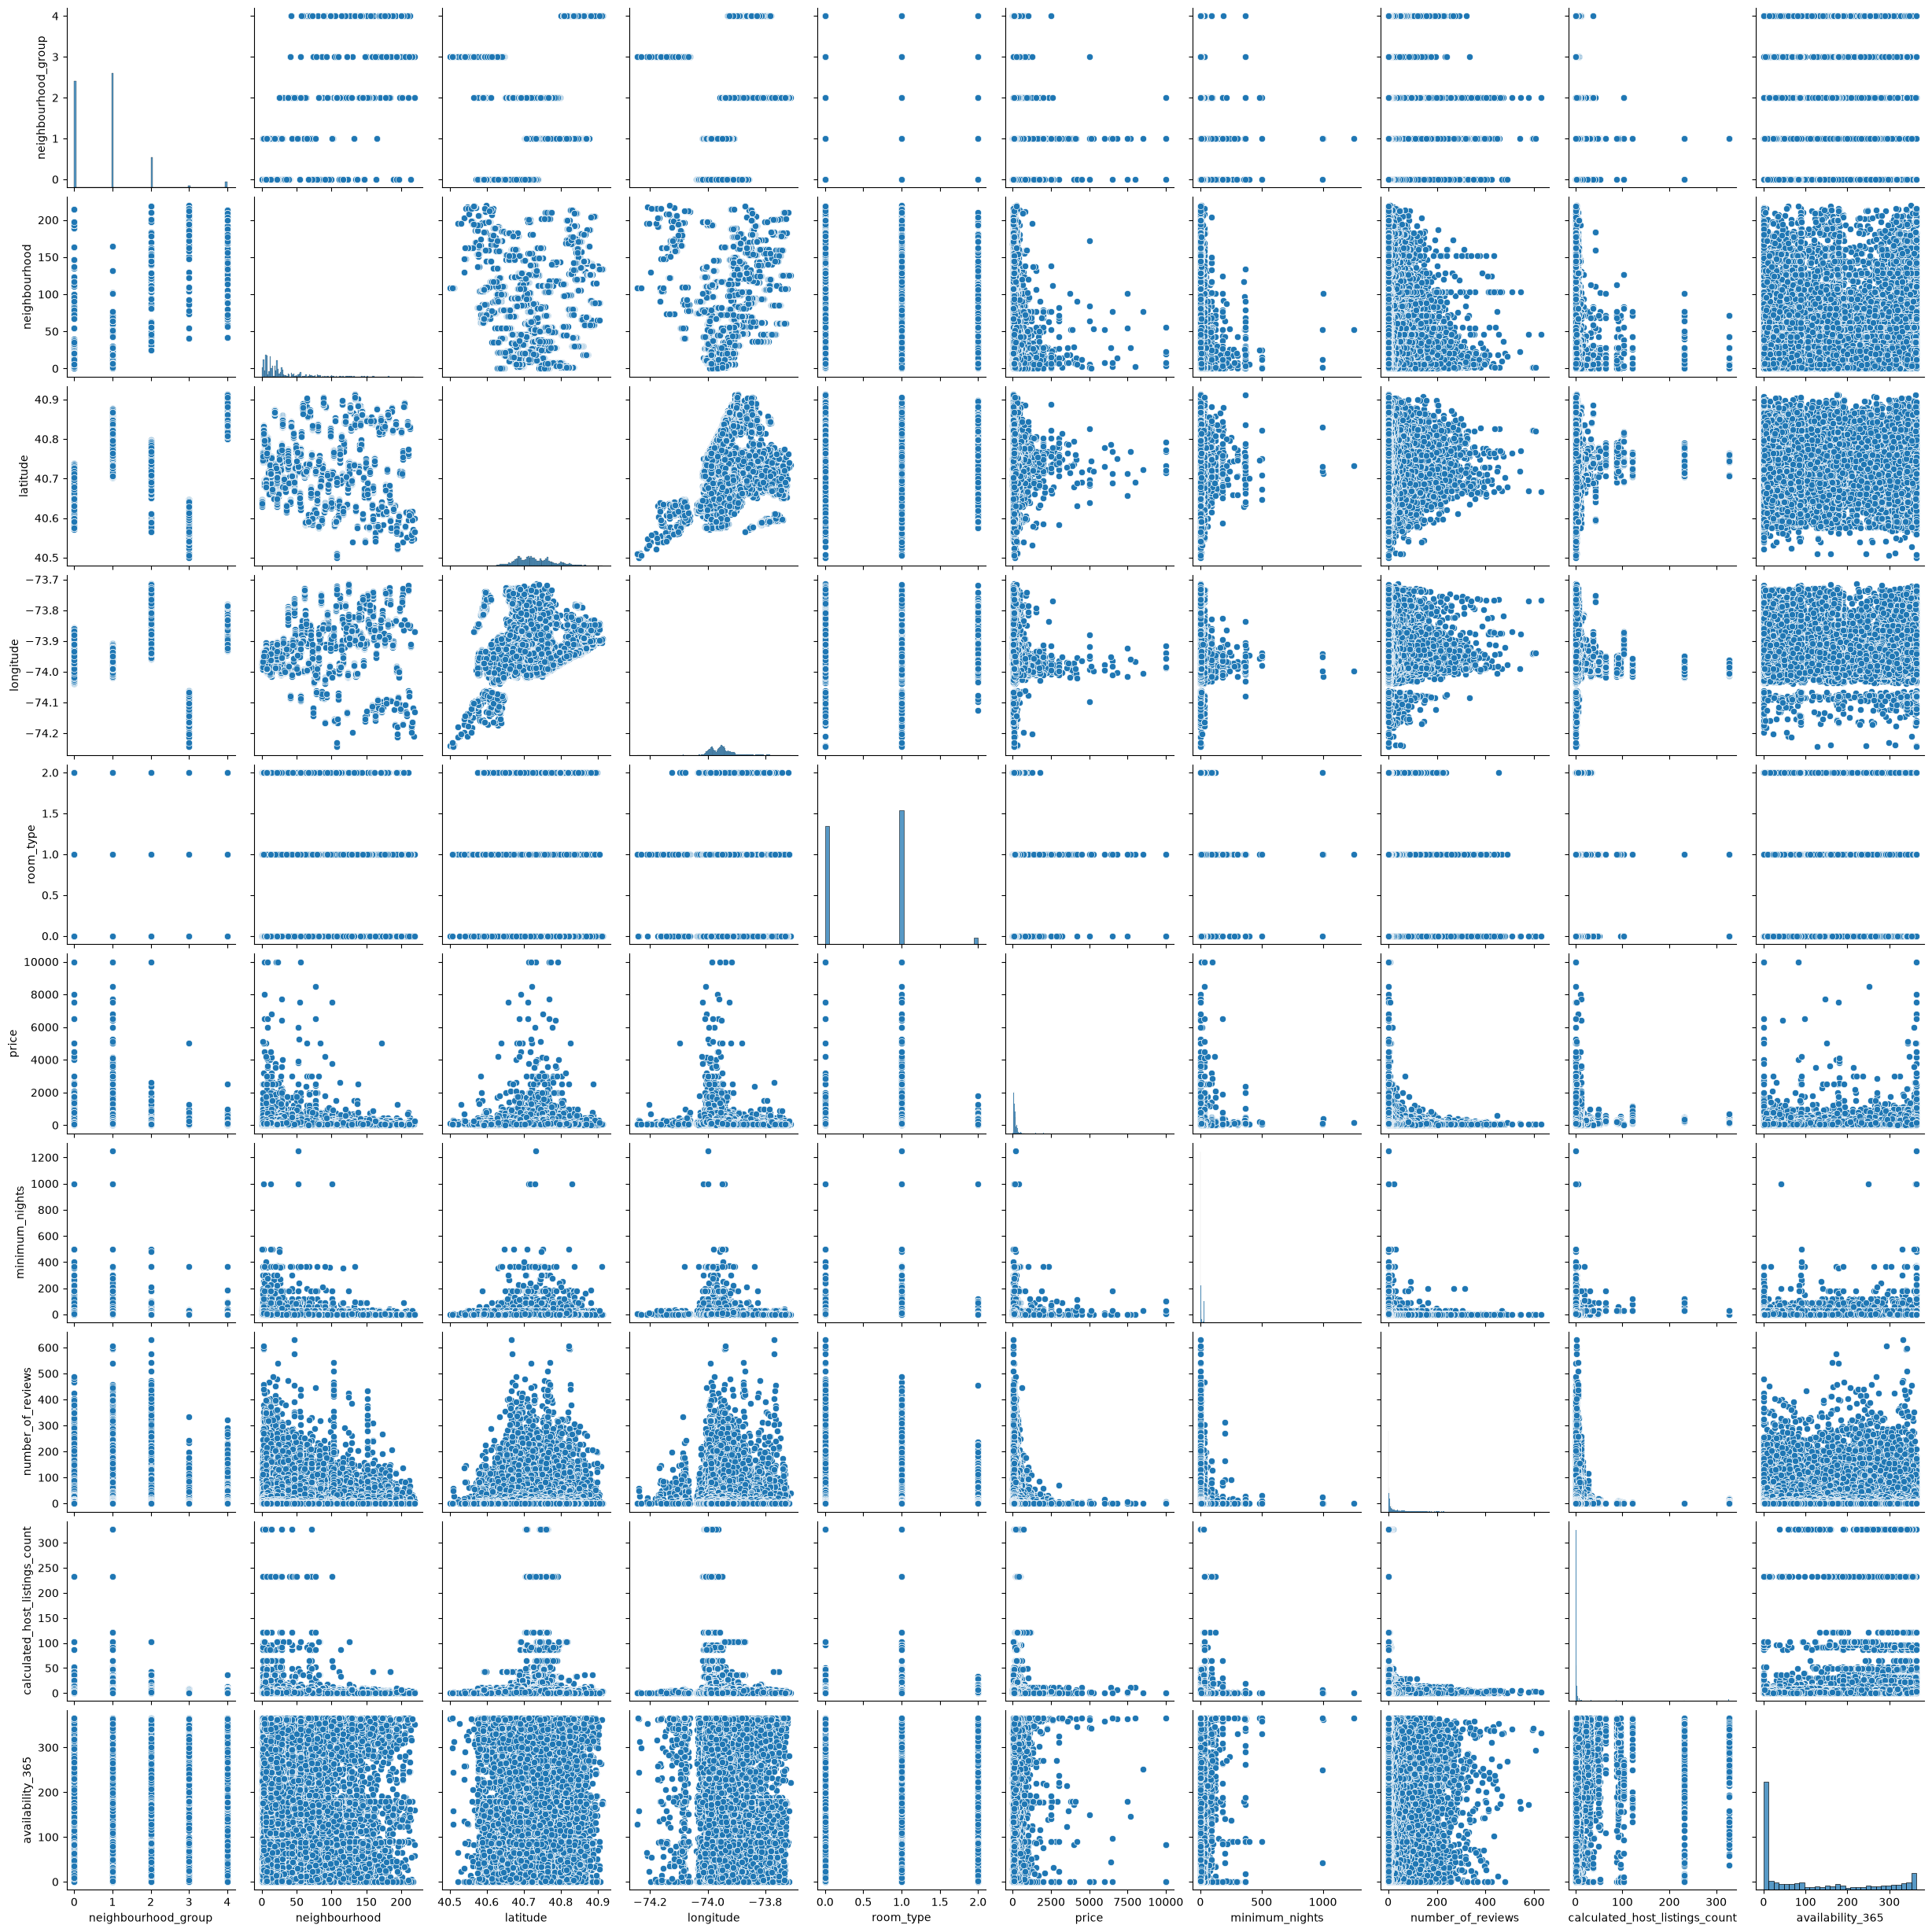

In [18]:
#Graficos 10*10
sns.pairplot(data=df)
plt.show()

## Paso 5: Ingenieria de Caracteristicas


## Analisis de Outliers

In [19]:
#Ayuda a tener valores como los totales, media,desviacion, min, max y percentiles 
df.describe()


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,0.786911,29.888782,40.728949,-73.952170,0.567113,152.720687,7.029962,23.274466,7.143982,112.781327
std,0.844386,34.676634,0.054530,0.046157,0.541249,240.154170,20.510550,44.550582,32.952519,131.622289
min,0.000000,0.000000,40.499790,-74.244420,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,7.500000,40.690100,-73.983070,0.000000,69.000000,1.000000,1.000000,1.000000,0.000000
50%,1.000000,19.000000,40.723070,-73.955680,1.000000,106.000000,3.000000,5.000000,1.000000,45.000000
75%,1.000000,37.000000,40.763115,-73.936275,1.000000,175.000000,5.000000,24.000000,2.000000,227.000000
max,4.000000,220.000000,40.913060,-73.712990,2.000000,10000.000000,1250.000000,629.000000,327.000000,365.000000


In [20]:
#Cuales son las columnas que se tienen

df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365'],
      dtype='str')

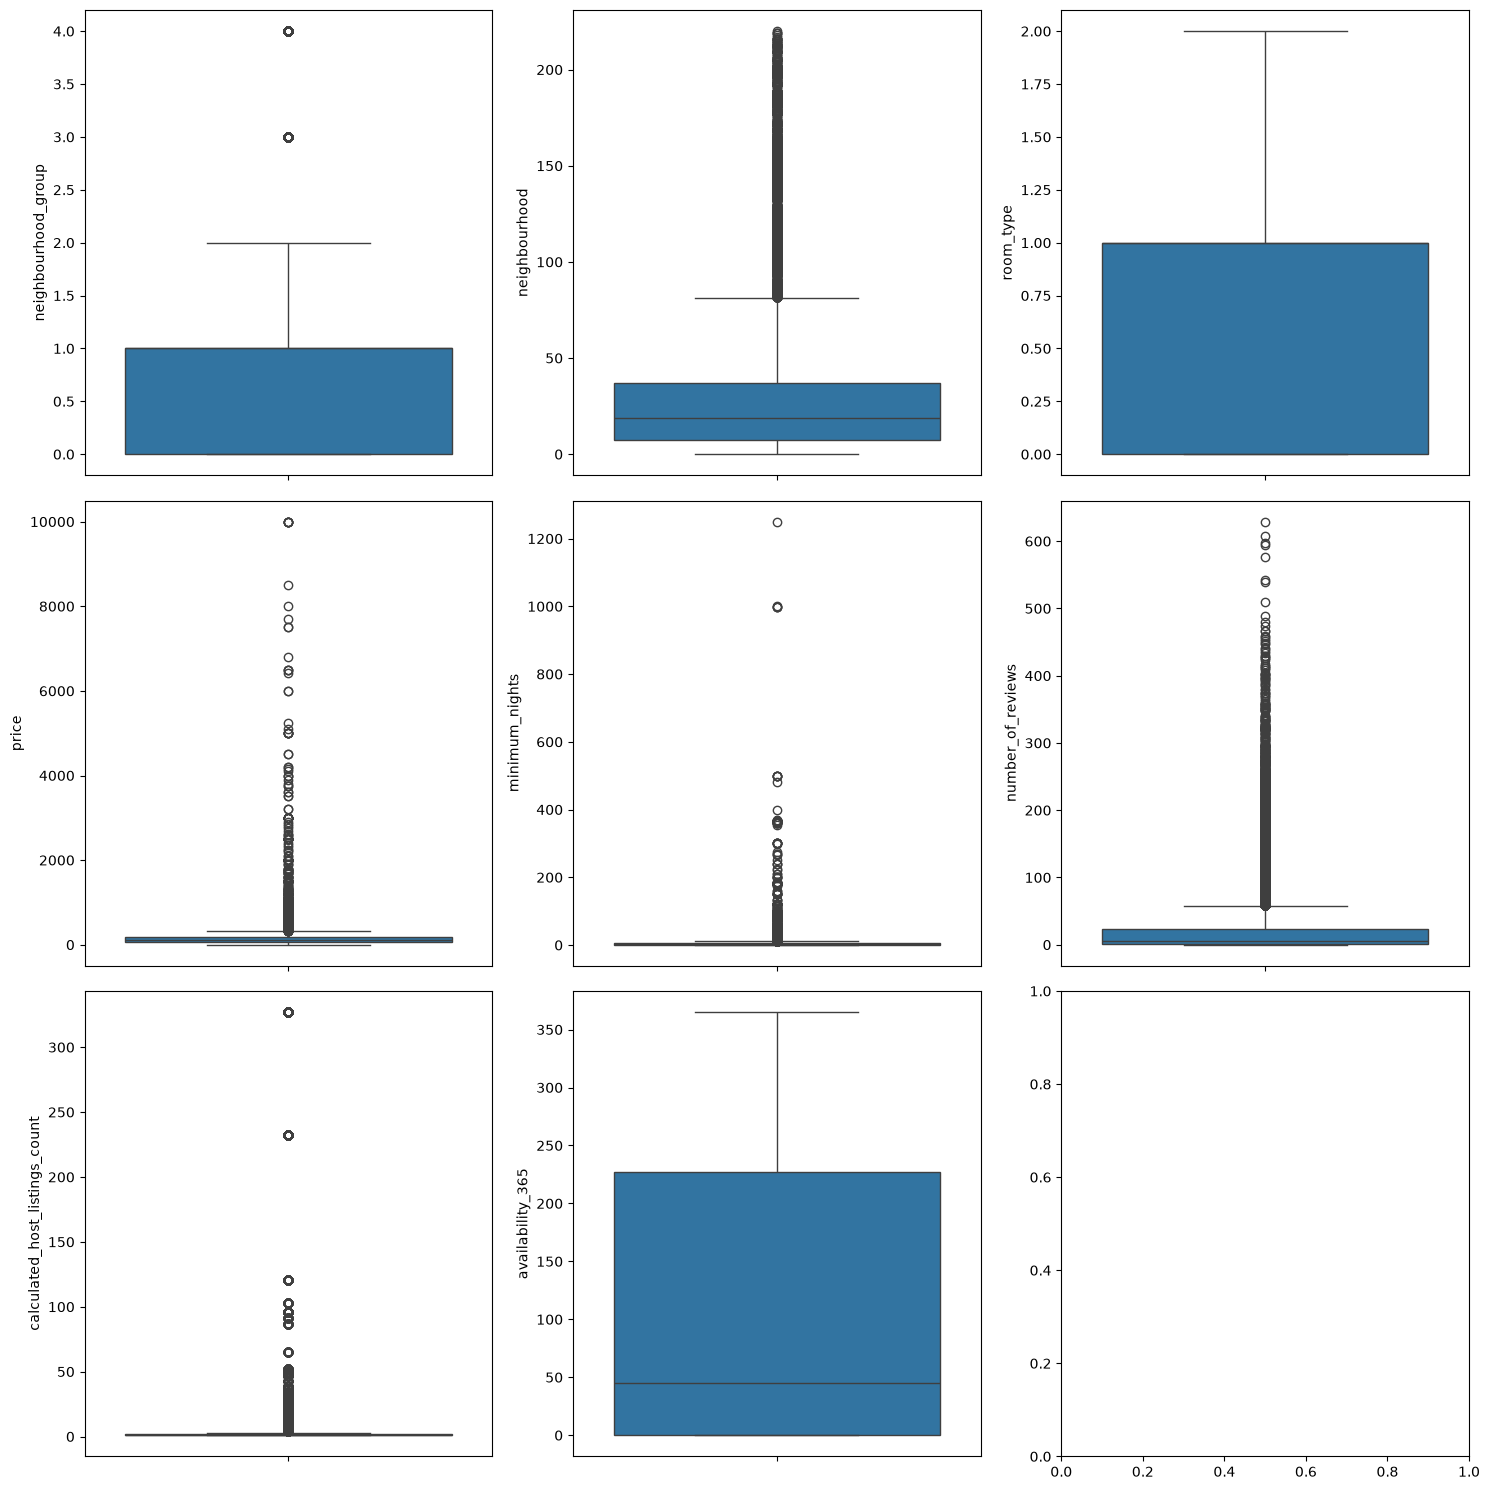

In [21]:
## Grafico de 3* 3
fig, axes = plt.subplots(3,3,figsize=(15,15))

columnas = ['neighbourhood_group', 'neighbourhood',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365']

fila = 0
col = 0


for columna in columnas:
    sns.boxplot(ax=axes[fila,col],data=df,y=columna)
    col +=1
    if col == 3:
        col = 0
        fila += 1

plt.tight_layout()
plt.show()

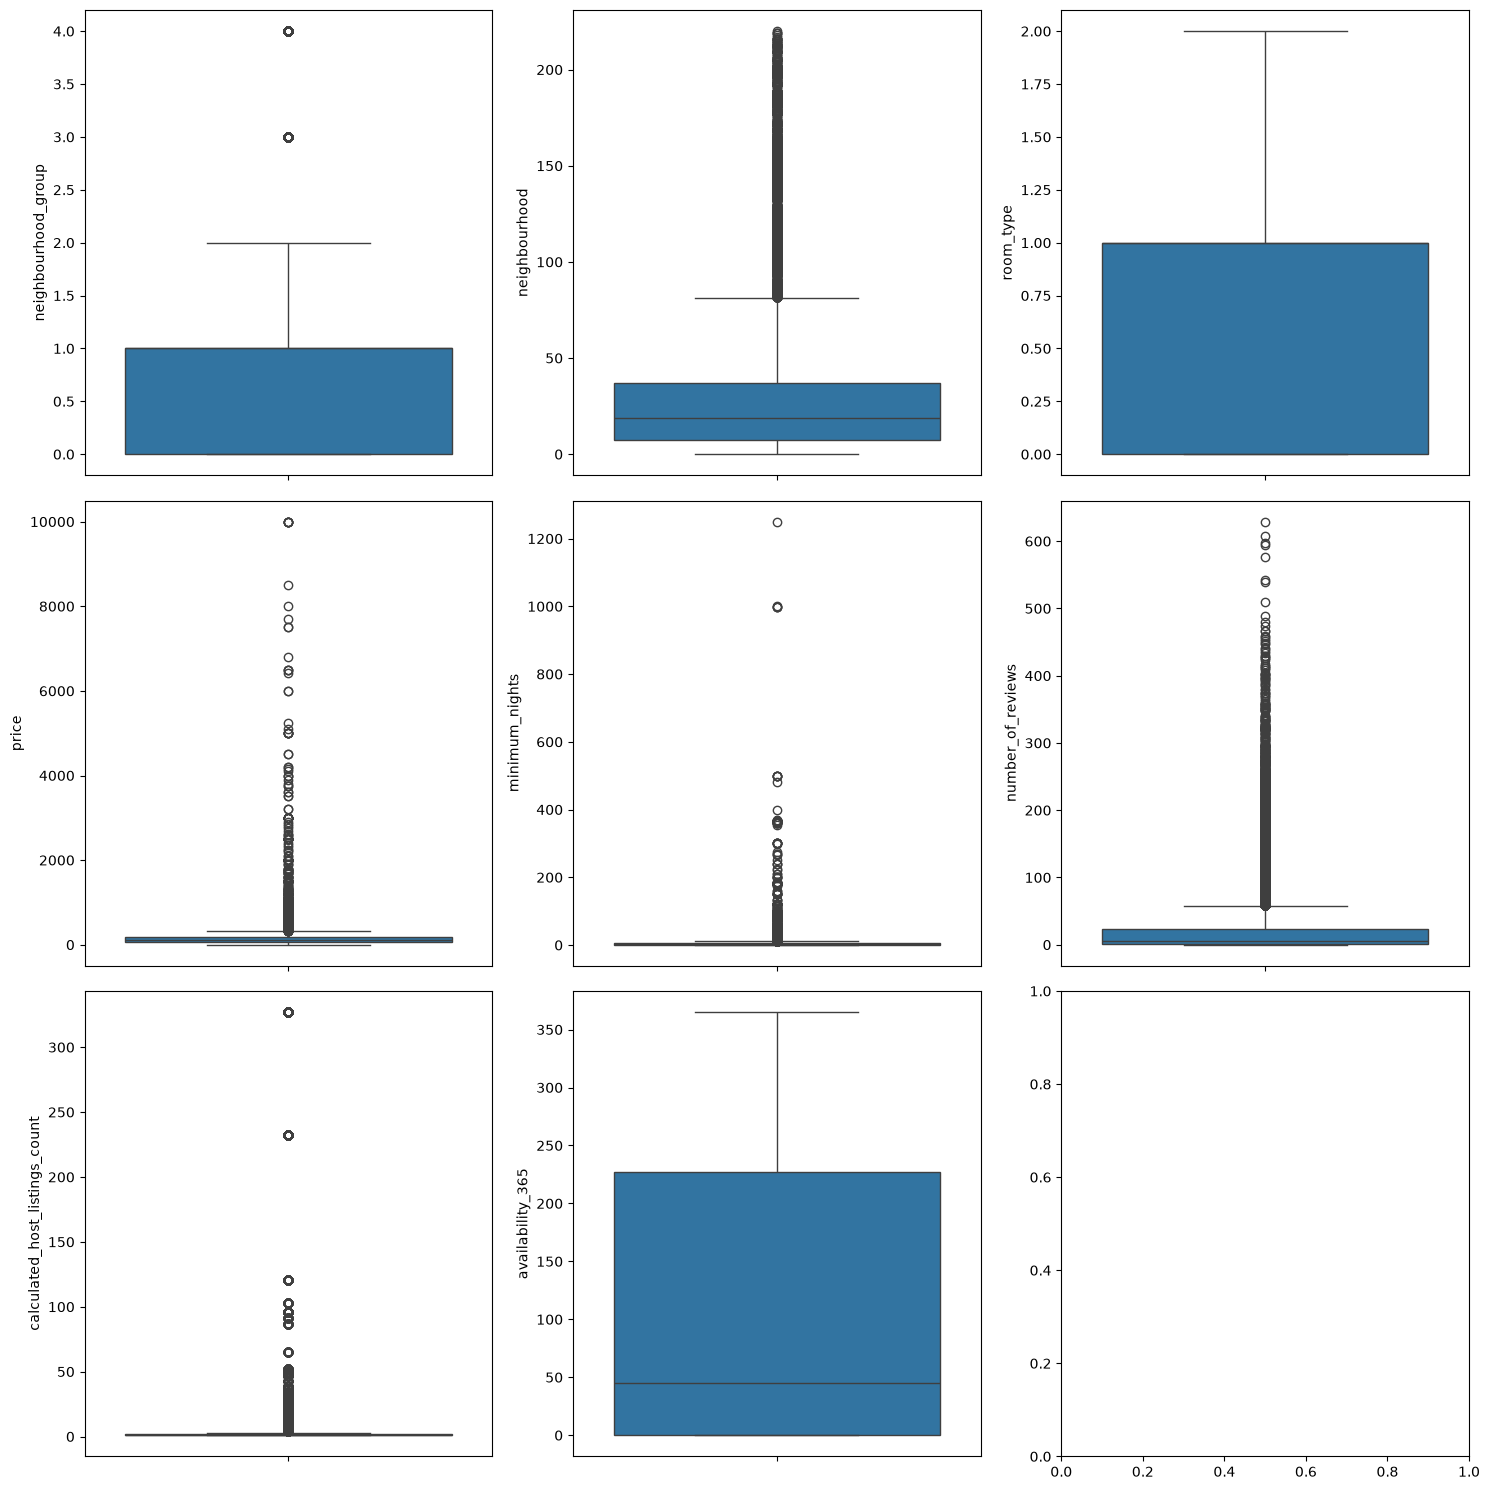

In [22]:
fig, axes = plt.subplots(3,3,figsize=(15,15))

sns.boxplot(ax=axes[0,0],data=df,y='neighbourhood_group')
sns.boxplot(ax=axes[0,1],data=df,y='neighbourhood')
sns.boxplot(ax=axes[0,2],data=df,y='room_type')
sns.boxplot(ax=axes[1,0],data=df,y='price')
sns.boxplot(ax=axes[1,1],data=df,y='minimum_nights')
sns.boxplot(ax=axes[1,2],data=df,y='number_of_reviews')
sns.boxplot(ax=axes[2,0],data=df,y='calculated_host_listings_count')
sns.boxplot(ax=axes[2,1],data=df,y='availability_365')

plt.tight_layout()
plt.show()

In [23]:
price_stats = df['price'].describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [24]:
price_iqr = price_stats['75%']- price_stats['25%']
limite_superior = price_stats['75%'] + 1.5 * price_iqr
calculo = price_stats['25%'] - 1.5 * price_iqr
limite_inferior = calculo if calculo > 0 else 0
print(f'limite superior para precio: {limite_superior}')
print(f'limite inferior para precio: {limite_inferior}')

limite superior para precio: 334.0
limite inferior para precio: 0


In [25]:
df = df[df['price']> 0]
df.shape

(48884, 10)

In [26]:
columnas = ['price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365']

for columna in columnas:
       stats = df[columna].describe()
       iqr = stats['75%']- stats['25%']
       limite_superior = stats['75%'] + 1.5 * iqr
       calculo = stats['25%'] - 1.5 * iqr
       limite_inferior = calculo if calculo > 0 else 0
       print(f'limite superior para {columna}: {limite_superior}')
       print(f'limite inferior para {columna }: {limite_inferior}')

limite superior para price: 334.0
limite inferior para price: 0
limite superior para minimum_nights: 11.0
limite inferior para minimum_nights: 0
limite superior para number_of_reviews: 58.5
limite inferior para number_of_reviews: 0
limite superior para calculated_host_listings_count: 3.5
limite inferior para calculated_host_listings_count: 0
limite superior para availability_365: 567.5
limite inferior para availability_365: 0


In [27]:
df = df[df['minimum_nights']<= 15]
df.shape

(43265, 10)

In [28]:
df = df[df['calculated_host_listings_count']<= 4]
df.shape

(40308, 10)

In [29]:
df = df[df['availability_365']<= 568]
df.shape

(40308, 10)

## Analisis de Valores Faltantes

In [30]:
df.isnull().sum().sort_values(ascending = False)

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

## Paso 6: Seleccion de Variables

## Escalamiento de Variables

In [31]:
from sklearn.preprocessing import MinMaxScaler

columnas = ['neighbourhood_group', 'neighbourhood',
       'room_type', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365']
scaler = MinMaxScaler()
scal_variables = scaler.fit_transform(df[columnas])
df_scaler = pd.DataFrame(scal_variables, index = df.index, columns = columnas)
df_scaler['price'] = df['price']
df_scaler.head()

,neighbourhood_group,neighbourhood,room_type,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,price
1,0.25,0.004545,0.5,0.000000,0.071542,0.333333,0.972603,225
2,0.25,0.009091,0.0,0.142857,0.000000,0.000000,1.000000,150
3,0.00,0.013636,0.5,0.000000,0.429253,0.000000,0.531507,89
4,0.25,0.018182,0.5,0.642857,0.014308,0.000000,0.000000,80
5,0.25,0.022727,0.5,0.142857,0.117647,0.000000,0.353425,200


## Seleccion de Variables

In [32]:
from sklearn.feature_selection import chi2,SelectKBest
from sklearn.model_selection import train_test_split

X = df_scaler.drop('price',axis=1)
y = df_scaler['price']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

modelo_seleccion = SelectKBest(chi2,k=4)
modelo_seleccion.fit(X_train,y_train)
ix = modelo_seleccion.get_support()
X_train_sel = pd.DataFrame(modelo_seleccion.transform(X_train),columns=X_train.columns.values[ix])
X_test_sel = pd.DataFrame(modelo_seleccion.transform(X_test),columns=X_test.columns.values[ix])

X_train_sel.head()

,neighbourhood,room_type,calculated_host_listings_count,availability_365
0,0.009091,0.0,0.000000,0.000000
1,0.068182,0.5,0.666667,0.016438
2,0.172727,0.5,0.000000,0.630137
3,0.009091,0.0,0.333333,0.041096
4,0.154545,0.5,0.000000,0.000000


In [33]:
X_train_sel['price'] = list(y_train)
X_test_sel['price'] = list(y_test)

X_train_sel.to_csv('../data/processed/train_limpio.csv',index=False)
X_test_sel.to_csv('../data/processed/test_limpio.csv',index=False)